# Differentiable Programming Patterns

This tutorial covers common patterns and techniques for differentiable programming, helping you choose the right approach for different problems.

**Topics covered:**
1. Unrolled vs implicit differentiation
2. Deep Equilibrium Models (DEQ)
3. Differentiating through argmin
4. Physics-informed constraints
5. Higher-order derivatives
6. Differentiable control flow
7. Soft operations and relaxations
8. Pattern selection guide

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap, hessian, jacfwd, jacrev
from jax import lax
from jax import custom_vjp
import equinox as eqx
import optax
import optimistix as optx
import matplotlib.pyplot as plt
from functools import partial

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.8.2


## 1. Unrolled vs Implicit Differentiation

When differentiating through iterative algorithms (optimization, fixed-point), you have two choices:

**Unrolled differentiation:**
- Backprop through each iteration
- Memory: O(iterations)
- Exact for finite iterations

**Implicit differentiation:**
- Use implicit function theorem at convergence
- Memory: O(1)
- Exact only at true fixed point

In [2]:
# Example: Fixed-point iteration x = tanh(Wx + b)

def fixed_point_unrolled(W, b, x0, n_iter=20):
    """
    Unrolled: backprop through all iterations.
    Memory grows with n_iter.
    """
    x = x0
    for _ in range(n_iter):
        x = jnp.tanh(W @ x + b)
    return x

@partial(custom_vjp, nondiff_argnums=(3, 4))
def fixed_point_implicit(W, b, x0, n_iter=20, tol=1e-6):
    """
    Implicit: only differentiate at convergence.
    Memory is O(1).
    """
    x = x0
    for _ in range(n_iter):
        x_new = jnp.tanh(W @ x + b)
        if jnp.max(jnp.abs(x_new - x)) < tol:
            break
        x = x_new
    return x

def fixed_point_implicit_fwd(W, b, x0, n_iter, tol):
    x_star = fixed_point_implicit(W, b, x0, n_iter, tol)
    return x_star, (W, b, x_star)

def fixed_point_implicit_bwd(n_iter, tol, res, g):
    """
    Implicit differentiation:
    x* = tanh(W @ x* + b)
    
    By implicit function theorem:
    dx*/dW = (I - J)^{-1} @ d(tanh)/dW
    where J = d(tanh(Wx+b))/dx = diag(1 - tanh²) @ W
    """
    W, b, x_star = res
    
    # Jacobian of tanh(Wx + b) w.r.t. x at x*
    tanh_val = jnp.tanh(W @ x_star + b)
    dtanh = 1 - tanh_val ** 2  # Derivative of tanh
    J = jnp.diag(dtanh) @ W  # d(tanh(Wx+b))/dx
    
    # Solve (I - J)^T @ v = g for v
    # This gives us the vector to backprop through
    v = jnp.linalg.solve((jnp.eye(len(x_star)) - J).T, g)
    
    # Gradients
    grad_W = jnp.outer(dtanh * v, x_star)
    grad_b = dtanh * v
    grad_x0 = jnp.zeros_like(x_star)  # Fixed point doesn't depend on x0
    
    return grad_W, grad_b, grad_x0

fixed_point_implicit.defvjp(fixed_point_implicit_fwd, fixed_point_implicit_bwd)

# Compare
key = random.PRNGKey(0)
n = 5
W = random.normal(key, (n, n)) * 0.5  # Small weights for convergence
b = random.normal(random.PRNGKey(1), (n,)) * 0.1
x0 = jnp.zeros(n)

x_unrolled = fixed_point_unrolled(W, b, x0)
x_implicit = fixed_point_implicit(W, b, x0)

print(f"Unrolled solution: {x_unrolled}")
print(f"Implicit solution: {x_implicit}")
print(f"Match: {jnp.allclose(x_unrolled, x_implicit, atol=1e-5)}")

Unrolled solution: [-0.30860964  0.08742608 -0.21691494  0.02575145 -0.062345  ]
Implicit solution: [-0.30860964  0.08742608 -0.21691494  0.02575145 -0.062345  ]
Match: True


In [3]:
# Compare gradients

def loss_unrolled(W, b, x0):
    x = fixed_point_unrolled(W, b, x0, n_iter=50)
    return jnp.sum(x ** 2)

def loss_implicit(W, b, x0):
    x = fixed_point_implicit(W, b, x0, n_iter=50)
    return jnp.sum(x ** 2)

grad_W_unrolled = grad(loss_unrolled)(W, b, x0)
grad_W_implicit = grad(loss_implicit)(W, b, x0)

print("Gradient comparison:")
print(f"  Unrolled grad norm: {jnp.linalg.norm(grad_W_unrolled):.6f}")
print(f"  Implicit grad norm: {jnp.linalg.norm(grad_W_implicit):.6f}")
print(f"  Difference: {jnp.linalg.norm(grad_W_unrolled - grad_W_implicit):.6f}")

Gradient comparison:
  Unrolled grad norm: 5.332211
  Implicit grad norm: 5.357392
  Difference: 0.030426


In [4]:
# When to use each?

print("""
UNROLLED DIFFERENTIATION:
✓ Few iterations (< 100)
✓ Need gradients at intermediate steps
✓ Non-convergent iterations matter
✗ High memory for many iterations
✗ Vanishing/exploding gradients possible

IMPLICIT DIFFERENTIATION:
✓ Many iterations needed
✓ Memory efficient (O(1))
✓ Stable gradients
✗ Requires true convergence
✗ Need to solve linear system
✗ More complex implementation

RECOMMENDATION:
- Use unrolled for training (few iterations, need intermediate grads)
- Use implicit for inference-time optimization
- Use optimistix for automatic implicit diff
""")


UNROLLED DIFFERENTIATION:
✓ Few iterations (< 100)
✓ Need gradients at intermediate steps
✓ Non-convergent iterations matter
✗ High memory for many iterations
✗ Vanishing/exploding gradients possible

IMPLICIT DIFFERENTIATION:
✓ Many iterations needed
✓ Memory efficient (O(1))
✓ Stable gradients
✗ Requires true convergence
✗ Need to solve linear system
✗ More complex implementation

RECOMMENDATION:
- Use unrolled for training (few iterations, need intermediate grads)
- Use implicit for inference-time optimization
- Use optimistix for automatic implicit diff



## 2. Deep Equilibrium Models (DEQ)

DEQ models define the output as the fixed point of a neural network layer:

$$z^* = f_\theta(z^*, x)$$

This is equivalent to an infinitely deep network with weight sharing!

In [5]:
# DEQ Layer using optimistix

class DEQLayer(eqx.Module):
    """
    Deep Equilibrium Layer.
    Output is fixed point: z* = f(z*, x)
    """
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    input_proj: eqx.nn.Linear
    
    def __init__(self, input_dim, hidden_dim, *, key):
        keys = random.split(key, 3)
        self.input_proj = eqx.nn.Linear(input_dim, hidden_dim, key=keys[0])
        self.linear1 = eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[1])
        self.linear2 = eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[2])
    
    def f(self, z, x_proj):
        """One iteration: z_{k+1} = f(z_k, x)"""
        h = jax.nn.relu(self.linear1(z) + x_proj)
        return 0.5 * jnp.tanh(self.linear2(h))  # Contraction factor
    
    def __call__(self, x):
        # Project input
        x_proj = self.input_proj(x)
        
        # Find fixed point using optimistix
        def residual(z, args):
            return self.f(z, x_proj) - z
        
        z0 = jnp.zeros(x_proj.shape)
        solver = optx.Newton(rtol=1e-5, atol=1e-5)
        sol = optx.root_find(residual, solver, z0, max_steps=50, throw=False)
        
        return sol.value

# Test DEQ layer
key = random.PRNGKey(42)
deq = DEQLayer(input_dim=4, hidden_dim=8, key=key)

x = random.normal(key, (4,))
z_star = deq(x)

print(f"Input shape: {x.shape}")
print(f"Fixed point shape: {z_star.shape}")
print(f"Fixed point: {z_star}")

# Verify it's a fixed point
x_proj = deq.input_proj(x)
z_next = deq.f(z_star, x_proj)
print(f"\n|f(z*) - z*| = {jnp.max(jnp.abs(z_next - z_star)):.2e}")

Input shape: (4,)
Fixed point shape: (8,)
Fixed point: [ 0.03467625 -0.08210178  0.07491626 -0.12856947  0.16261056  0.19624736
 -0.08700007 -0.27254499]



|f(z*) - z*| = 1.11e-16


In [6]:
# Train DEQ model

class DEQClassifier(eqx.Module):
    deq: DEQLayer
    output: eqx.nn.Linear
    
    def __init__(self, input_dim, hidden_dim, output_dim, *, key):
        keys = random.split(key, 2)
        self.deq = DEQLayer(input_dim, hidden_dim, key=keys[0])
        self.output = eqx.nn.Linear(hidden_dim, output_dim, key=keys[1])
    
    def __call__(self, x):
        z = self.deq(x)
        return self.output(z)

# Create model and test gradient
model = DEQClassifier(input_dim=4, hidden_dim=8, output_dim=2, key=random.PRNGKey(0))

def loss_fn(model, x, y):
    logits = model(x)
    return jnp.sum((logits - y) ** 2)

x = random.normal(random.PRNGKey(1), (4,))
y = jnp.array([1.0, 0.0])

# Gradient flows through fixed point!
loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)

print(f"Loss: {loss:.4f}")
print(f"Gradient exists for DEQ layer: {grads.deq.linear1.weight is not None}")
print(f"DEQ linear1 grad norm: {jnp.linalg.norm(grads.deq.linear1.weight):.4f}")

Loss: 0.6543
Gradient exists for DEQ layer: True
DEQ linear1 grad norm: 0.0153


## 3. Differentiating Through Argmin

Many problems involve optimization as a layer:

$$y^*(\theta) = \arg\min_y f(y; \theta)$$

We want $\frac{dy^*}{d\theta}$. By implicit differentiation at the optimum:

$$\frac{dy^*}{d\theta} = -\left(\frac{\partial^2 f}{\partial y^2}\right)^{-1} \frac{\partial^2 f}{\partial y \partial \theta}$$

In [7]:
# Example: Quadratic optimization layer
# y* = argmin_y (1/2 y^T Q y - c^T y)
# Solution: y* = Q^{-1} c

def quadratic_layer_explicit(Q, c):
    """Direct solution (when available)."""
    return jnp.linalg.solve(Q, c)

def quadratic_layer_optx(Q, c):
    """Using optimistix minimization."""
    def objective(y, args):
        Q, c = args
        return 0.5 * y @ Q @ y - c @ y
    
    y0 = jnp.zeros_like(c)
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(objective, solver, y0, args=(Q, c), max_steps=100)
    return sol.value

# Test
n = 3
key = random.PRNGKey(0)
A = random.normal(key, (n, n))
Q = A @ A.T + jnp.eye(n)  # Positive definite
c = random.normal(random.PRNGKey(1), (n,))

y_explicit = quadratic_layer_explicit(Q, c)
y_optx = quadratic_layer_optx(Q, c)

print(f"Explicit: {y_explicit}")
print(f"Optimistix: {y_optx}")
print(f"Match: {jnp.allclose(y_explicit, y_optx, atol=1e-4)}")

Explicit: [-0.28116662 -0.29375909  0.05391175]
Optimistix: [-0.28116662 -0.29375909  0.05391175]
Match: True


In [8]:
# Gradient through argmin

def loss_with_argmin(Q, c, target):
    y_star = quadratic_layer_optx(Q, c)
    return jnp.sum((y_star - target) ** 2)

target = jnp.ones(n)

# Gradient w.r.t. c (easier case)
grad_c = grad(loss_with_argmin, argnums=1)(Q, c, target)
print(f"Gradient w.r.t. c: {grad_c}")

# Verify: dy*/dc = Q^{-1}, so dL/dc = 2(y* - target)^T Q^{-1}
y_star = quadratic_layer_optx(Q, c)
expected_grad_c = 2 * jnp.linalg.solve(Q.T, y_star - target)
print(f"Expected gradient: {expected_grad_c}")
print(f"Match: {jnp.allclose(grad_c, expected_grad_c, atol=1e-3)}")

Gradient w.r.t. c: [-0.99139051 -2.7250085  -0.64922416]


Expected gradient: [-0.99139051 -2.7250085  -0.64922416]
Match: True


In [9]:
# Constrained optimization layer
# y* = argmin_y ||y - c||^2 subject to Ay = b

def projection_layer(c, A, b):
    """
    Project c onto affine subspace {y : Ay = b}.
    Uses optimistix least squares.
    """
    def residual(y, args):
        c, A, b = args
        # Penalized objective: ||y - c||^2 + large * ||Ay - b||^2
        return jnp.concatenate([y - c, 100 * (A @ y - b)])
    
    y0 = c
    solver = optx.LevenbergMarquardt(rtol=1e-6, atol=1e-6)
    sol = optx.least_squares(residual, solver, y0, args=(c, A, b), max_steps=100)
    return sol.value

# Example: project onto plane x + y + z = 1
A = jnp.array([[1.0, 1.0, 1.0]])
b = jnp.array([1.0])
c = jnp.array([2.0, 0.0, 0.0])  # Point to project

y_proj = projection_layer(c, A, b)

print(f"Original point: {c}")
print(f"Projected point: {y_proj}")
print(f"Constraint Ay: {A @ y_proj} (should be {b})")

# Gradient flows through projection!
def proj_loss(c, A, b):
    y = projection_layer(c, A, b)
    return jnp.sum(y ** 2)

grad_c = grad(proj_loss)(c, A, b)
print(f"\nGradient w.r.t. c: {grad_c}")

Original point: [2. 0. 0.]
Projected point: [ 1.66667778 -0.33332222 -0.33332222]
Constraint Ay: [1.00003333] (should be [1.])



Gradient w.r.t. c: [ 2.66668889 -1.33331111 -1.33331111]


## 4. Physics-Informed Constraints

Embed physical constraints directly into differentiable models.

In [10]:
# Pattern 1: Soft constraints via penalty

def physics_loss_soft(params, x, y_data):
    """
    Soft constraint: add penalty term.
    Example: Mass conservation sum(y) = sum(x)
    """
    y_pred = model_fn(params, x)  # Some model
    
    # Data loss
    data_loss = jnp.mean((y_pred - y_data) ** 2)
    
    # Physics constraint penalty
    mass_violation = jnp.sum(y_pred) - jnp.sum(x)
    physics_loss = 1000 * mass_violation ** 2
    
    return data_loss + physics_loss

print("Soft constraints: Add penalty term")
print("+ Simple to implement")
print("+ Works with any constraint")
print("- Constraint only approximately satisfied")
print("- Need to tune penalty weight")

Soft constraints: Add penalty term
+ Simple to implement
+ Works with any constraint
- Constraint only approximately satisfied
- Need to tune penalty weight


In [11]:
# Pattern 2: Hard constraints via reparameterization

def enforce_mass_conservation(raw_output, total_mass):
    """
    Hard constraint: normalize to conserve mass.
    This is differentiable!
    """
    # Ensure non-negative
    positive_output = jax.nn.softplus(raw_output)
    # Normalize to sum to total_mass
    return positive_output / jnp.sum(positive_output) * total_mass

def enforce_positivity(x):
    """Ensure x > 0 via softplus."""
    return jax.nn.softplus(x)

def enforce_bounds(x, low, high):
    """Ensure low < x < high via sigmoid."""
    return low + (high - low) * jax.nn.sigmoid(x)

def enforce_simplex(logits):
    """Ensure x >= 0 and sum(x) = 1 via softmax."""
    return jax.nn.softmax(logits)

# Example
raw = jnp.array([1.0, -0.5, 2.0, 0.3])
total_mass = 10.0

conserved = enforce_mass_conservation(raw, total_mass)
print(f"Raw output: {raw}")
print(f"Conserved output: {conserved}")
print(f"Sum: {jnp.sum(conserved):.6f} (target: {total_mass})")

# Gradient flows through constraint!
grad_raw = grad(lambda r: jnp.sum(enforce_mass_conservation(r, total_mass) ** 2))(raw)
print(f"\nGradient w.r.t. raw: {grad_raw}")

Raw output: [ 1.  -0.5  2.   0.3]
Conserved output: [2.75396479 0.9941593  4.46025716 1.79161875]
Sum: 10.000000 (target: 10.0)



Gradient w.r.t. raw: [-1.26839861 -3.44158073  4.77508003 -3.31520906]


In [12]:
# Pattern 3: Conservation via architecture

class ConservativeNetwork(eqx.Module):
    """
    Network that inherently conserves mass.
    Outputs redistribution matrix, not absolute values.
    """
    layers: list
    
    def __init__(self, n_species, hidden_dim, *, key):
        keys = random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(n_species, hidden_dim, key=keys[0]),
            eqx.nn.Linear(hidden_dim, hidden_dim, key=keys[1]),
            eqx.nn.Linear(hidden_dim, n_species * n_species, key=keys[2]),
        ]
    
    def __call__(self, x):
        """x: input composition, returns output composition."""
        n = len(x)
        
        # Compute redistribution logits
        h = x
        for layer in self.layers[:-1]:
            h = jax.nn.relu(layer(h))
        logits = self.layers[-1](h).reshape(n, n)
        
        # Softmax over columns: each column sums to 1
        # R[i,j] = fraction of species j that becomes species i
        R = jax.nn.softmax(logits, axis=0)
        
        # Apply redistribution: y = R @ x
        # This conserves mass: sum(y) = sum(R @ x) = sum(x) since columns sum to 1
        return R @ x

# Test
net = ConservativeNetwork(n_species=4, hidden_dim=16, key=random.PRNGKey(0))
x = jnp.array([10.0, 5.0, 3.0, 2.0])  # Total = 20

y = net(x)
print(f"Input: {x}, sum = {jnp.sum(x)}")
print(f"Output: {y}, sum = {jnp.sum(y):.6f}")
print(f"Mass conserved: {jnp.allclose(jnp.sum(x), jnp.sum(y))}")

Input: [10.  5.  3.  2.], sum = 20.0
Output: [5.46178306 3.54354348 5.44448837 5.55018509], sum = 20.000000
Mass conserved: True


## 5. Higher-Order Derivatives

JAX supports arbitrary-order derivatives through nested transformations.

In [13]:
# Hessian computation

def f(x):
    """Rosenbrock function."""
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

x = jnp.array([0.5, 0.5])

# First derivative (gradient)
gradient = grad(f)(x)

# Second derivative (Hessian) - multiple ways
hess1 = hessian(f)(x)  # Direct
hess2 = jacfwd(jacrev(f))(x)  # Forward-over-reverse
hess3 = jacrev(jacfwd(f))(x)  # Reverse-over-forward

print(f"Gradient: {gradient}")
print(f"\nHessian (direct):")
print(hess1)
print(f"\nAll methods match: {jnp.allclose(hess1, hess2) and jnp.allclose(hess1, hess3)}")

Gradient: [-51.  50.]

Hessian (direct):
[[ 102. -200.]
 [-200.  200.]]

All methods match: True


In [14]:
# Hessian-vector product (efficient for large problems)

def hvp(f, x, v):
    """Compute Hessian-vector product: H @ v."""
    return grad(lambda x: jnp.dot(grad(f)(x), v))(x)

v = jnp.array([1.0, 0.0])
hvp_result = hvp(f, x, v)

# Verify against full Hessian
expected = hess1 @ v

print(f"HVP result: {hvp_result}")
print(f"H @ v:      {expected}")
print(f"Match: {jnp.allclose(hvp_result, expected)}")

print("\nHVP is O(n) while full Hessian is O(n²)!")

HVP result: [ 102. -200.]
H @ v:      [ 102. -200.]
Match: True

HVP is O(n) while full Hessian is O(n²)!


In [15]:
# Newton's method using Hessian

def newton_step(f, x):
    """One step of Newton's method."""
    g = grad(f)(x)
    H = hessian(f)(x)
    return x - jnp.linalg.solve(H, g)

# Optimize Rosenbrock
x = jnp.array([0.0, 0.0])
print("Newton's method on Rosenbrock:")
for i in range(10):
    x = newton_step(f, x)
    print(f"  Step {i+1}: x = [{x[0]:.6f}, {x[1]:.6f}], f(x) = {f(x):.2e}")

print(f"\nOptimum: [1, 1], found: [{x[0]:.6f}, {x[1]:.6f}]")

Newton's method on Rosenbrock:


  Step 1: x = [1.000000, 0.000000], f(x) = 1.00e+02
  Step 2: x = [1.000000, 1.000000], f(x) = 0.00e+00
  Step 3: x = [1.000000, 1.000000], f(x) = 0.00e+00
  Step 4: x = [1.000000, 1.000000], f(x) = 0.00e+00


  Step 5: x = [1.000000, 1.000000], f(x) = 0.00e+00
  Step 6: x = [1.000000, 1.000000], f(x) = 0.00e+00
  Step 7: x = [1.000000, 1.000000], f(x) = 0.00e+00
  Step 8: x = [1.000000, 1.000000], f(x) = 0.00e+00
  Step 9: x = [1.000000, 1.000000], f(x) = 0.00e+00


  Step 10: x = [1.000000, 1.000000], f(x) = 0.00e+00

Optimum: [1, 1], found: [1.000000, 1.000000]


In [16]:
# Third and higher derivatives

def g(x):
    return jnp.sin(x)

x = 0.5

# Derivatives of sin(x)
d1 = grad(g)(x)                    # cos(x)
d2 = grad(grad(g))(x)              # -sin(x)
d3 = grad(grad(grad(g)))(x)        # -cos(x)
d4 = grad(grad(grad(grad(g))))(x)  # sin(x)

print(f"f(x) = sin(x) at x = {x}")
print(f"f(x)   = {g(x):.6f} (sin)")
print(f"f'(x)  = {d1:.6f} (cos)")
print(f"f''(x) = {d2:.6f} (-sin)")
print(f"f'''(x)= {d3:.6f} (-cos)")
print(f"f''''(x)={d4:.6f} (sin)")

f(x) = sin(x) at x = 0.5
f(x)   = 0.479426 (sin)
f'(x)  = 0.877583 (cos)
f''(x) = -0.479426 (-sin)
f'''(x)= -0.877583 (-cos)
f''''(x)=0.479426 (sin)


## 6. Differentiable Control Flow

JAX provides differentiable versions of control flow: `lax.cond`, `lax.switch`, `lax.while_loop`, `lax.fori_loop`.

In [17]:
# lax.cond - differentiable if-else

def cond_example(x, threshold):
    """
    Different computation based on condition.
    Gradient flows through the taken branch.
    """
    return lax.cond(
        x > threshold,
        lambda x: x ** 2,      # True branch
        lambda x: 2 * x,       # False branch
        x
    )

# Test
print("lax.cond example: f(x) = x² if x > 0.5 else 2x")
for x in [0.3, 0.7]:
    x = jnp.array(x)
    y = cond_example(x, 0.5)
    dy = grad(cond_example)(x, 0.5)
    print(f"  x = {x}: f(x) = {y:.3f}, f'(x) = {dy:.3f}")

lax.cond example: f(x) = x² if x > 0.5 else 2x


  x = 0.3: f(x) = 0.600, f'(x) = 2.000


  x = 0.7: f(x) = 0.490, f'(x) = 1.400


In [18]:
# lax.switch - differentiable multi-way branch

def switch_example(x, mode):
    """
    Select computation based on integer mode.
    """
    branches = [
        lambda x: x,           # Mode 0: identity
        lambda x: x ** 2,      # Mode 1: square
        lambda x: jnp.sin(x),  # Mode 2: sin
        lambda x: jnp.exp(x),  # Mode 3: exp
    ]
    return lax.switch(mode, branches, x)

x = jnp.array(0.5)
print("lax.switch example:")
for mode in range(4):
    y = switch_example(x, mode)
    dy = grad(switch_example)(x, mode)
    names = ['identity', 'square', 'sin', 'exp']
    print(f"  Mode {mode} ({names[mode]}): f({x}) = {y:.4f}, f'({x}) = {dy:.4f}")

lax.switch example:


  Mode 0 (identity): f(0.5) = 0.5000, f'(0.5) = 1.0000


  Mode 1 (square): f(0.5) = 0.2500, f'(0.5) = 1.0000


  Mode 2 (sin): f(0.5) = 0.4794, f'(0.5) = 0.8776


  Mode 3 (exp): f(0.5) = 1.6487, f'(0.5) = 1.6487


In [19]:
# Pattern: Soft switching (always differentiable)

def soft_switch(x, weights):
    """
    Weighted combination of branches.
    Differentiable w.r.t. both x and weights.
    """
    branches = jnp.array([
        x,
        x ** 2,
        jnp.sin(x),
        jnp.exp(x)
    ])
    # Soft weights via softmax
    soft_weights = jax.nn.softmax(weights)
    return jnp.sum(soft_weights * branches)

x = jnp.array(0.5)
weights = jnp.array([0.0, 1.0, 0.0, 0.0])  # Prefer square

y = soft_switch(x, weights)
grad_x = grad(soft_switch)(x, weights)
grad_w = grad(soft_switch, argnums=1)(x, weights)

print("Soft switch (all branches contribute):")
print(f"  Output: {y:.4f}")
print(f"  d/dx: {grad_x:.4f}")
print(f"  d/dweights: {grad_w}")

Soft switch (all branches contribute):
  Output: 0.5784
  d/dx: 1.0920
  d/dweights: [-0.01371846 -0.15613235 -0.01731647  0.18716728]


## 7. Soft Operations and Relaxations

Replace non-differentiable operations with smooth approximations.

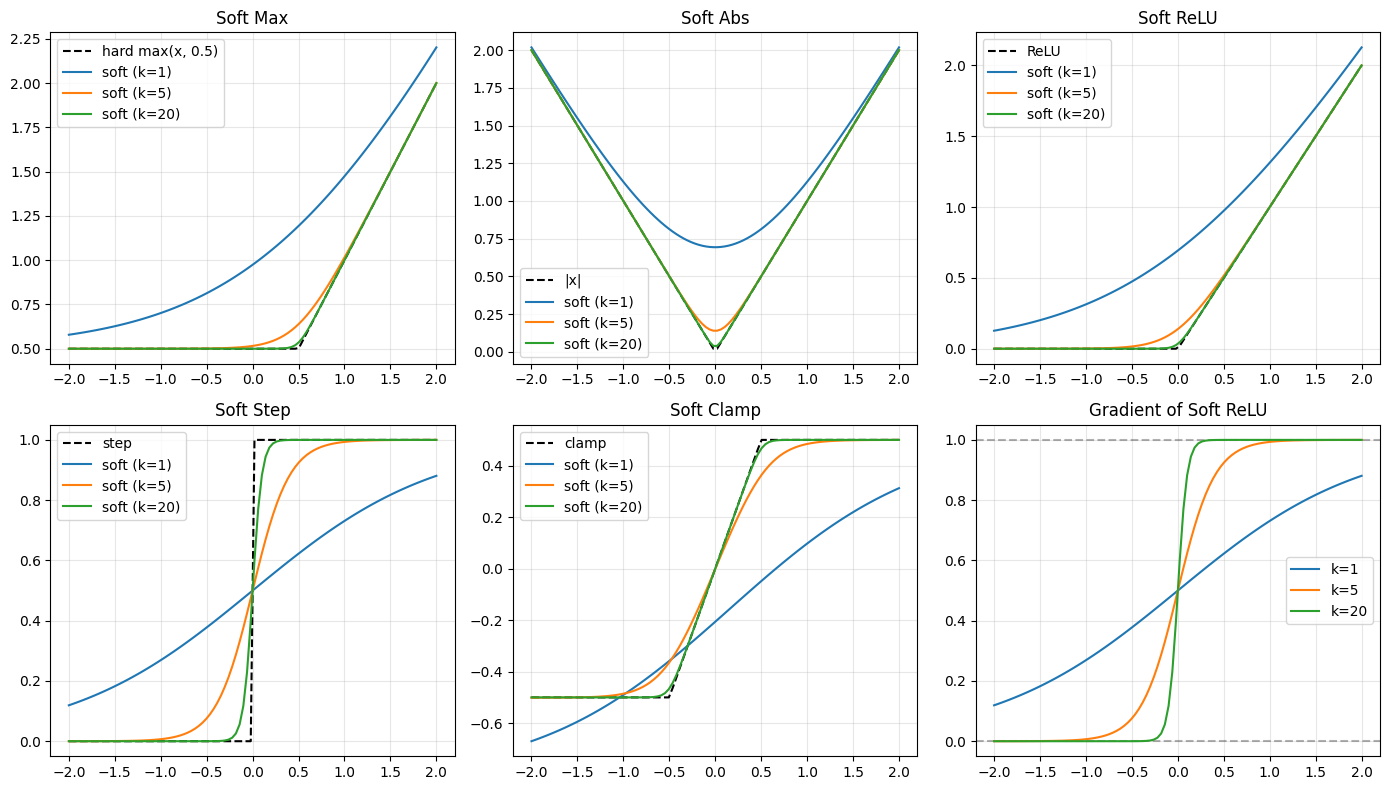

In [20]:
# Soft operations collection

def soft_max(a, b, sharpness=10.0):
    """Smooth approximation to max(a, b)."""
    return jax.nn.logsumexp(jnp.array([a, b]) * sharpness) / sharpness

def soft_min(a, b, sharpness=10.0):
    """Smooth approximation to min(a, b)."""
    return -soft_max(-a, -b, sharpness)

def soft_abs(x, sharpness=10.0):
    """Smooth approximation to |x|."""
    return soft_max(x, -x, sharpness)

def soft_relu(x, sharpness=10.0):
    """Smooth approximation to max(0, x)."""
    return soft_max(x, 0.0, sharpness)

def soft_step(x, sharpness=10.0):
    """Smooth approximation to step function (0 if x<0, 1 if x>0)."""
    return jax.nn.sigmoid(sharpness * x)

def soft_clamp(x, low, high, sharpness=10.0):
    """Smooth approximation to clamp(x, low, high)."""
    return soft_min(soft_max(x, low, sharpness), high, sharpness)

# Visualize
x = jnp.linspace(-2, 2, 100)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Max
axes[0, 0].plot(x, jnp.maximum(x, 0.5), 'k--', label='hard max(x, 0.5)')
for s in [1, 5, 20]:
    axes[0, 0].plot(x, vmap(lambda xi: soft_max(xi, 0.5, s))(x), label=f'soft (k={s})')
axes[0, 0].legend()
axes[0, 0].set_title('Soft Max')
axes[0, 0].grid(True, alpha=0.3)

# Abs
axes[0, 1].plot(x, jnp.abs(x), 'k--', label='|x|')
for s in [1, 5, 20]:
    axes[0, 1].plot(x, vmap(lambda xi: soft_abs(xi, s))(x), label=f'soft (k={s})')
axes[0, 1].legend()
axes[0, 1].set_title('Soft Abs')
axes[0, 1].grid(True, alpha=0.3)

# ReLU
axes[0, 2].plot(x, jnp.maximum(x, 0), 'k--', label='ReLU')
for s in [1, 5, 20]:
    axes[0, 2].plot(x, vmap(lambda xi: soft_relu(xi, s))(x), label=f'soft (k={s})')
axes[0, 2].legend()
axes[0, 2].set_title('Soft ReLU')
axes[0, 2].grid(True, alpha=0.3)

# Step
axes[1, 0].plot(x, (x > 0).astype(float), 'k--', label='step')
for s in [1, 5, 20]:
    axes[1, 0].plot(x, vmap(lambda xi: soft_step(xi, s))(x), label=f'soft (k={s})')
axes[1, 0].legend()
axes[1, 0].set_title('Soft Step')
axes[1, 0].grid(True, alpha=0.3)

# Clamp
axes[1, 1].plot(x, jnp.clip(x, -0.5, 0.5), 'k--', label='clamp')
for s in [1, 5, 20]:
    axes[1, 1].plot(x, vmap(lambda xi: soft_clamp(xi, -0.5, 0.5, s))(x), label=f'soft (k={s})')
axes[1, 1].legend()
axes[1, 1].set_title('Soft Clamp')
axes[1, 1].grid(True, alpha=0.3)

# Gradients of soft ReLU
axes[1, 2].axhline(0, color='k', linestyle='--', alpha=0.3)
axes[1, 2].axhline(1, color='k', linestyle='--', alpha=0.3)
for s in [1, 5, 20]:
    grads = vmap(grad(lambda xi: soft_relu(xi, s)))(x)
    axes[1, 2].plot(x, grads, label=f'k={s}')
axes[1, 2].legend()
axes[1, 2].set_title('Gradient of Soft ReLU')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Pattern Selection Guide

Quick reference for choosing the right pattern.

In [21]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    DIFFERENTIABLE PROGRAMMING PATTERN GUIDE                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ITERATIVE ALGORITHMS                                                        ║
║  ───────────────────                                                         ║
║  • Few iterations (<100): Unrolled differentiation                          ║
║  • Many iterations: Implicit differentiation                                 ║
║  • Fixed-point problems: optimistix.fixed_point                             ║
║  • Root finding: optimistix.root_find                                       ║
║                                                                              ║
║  OPTIMIZATION LAYERS                                                         ║
║  ───────────────────                                                         ║
║  • Unconstrained: optimistix.minimise                                       ║
║  • Least squares: optimistix.least_squares                                  ║
║  • Quadratic: Closed form + implicit diff                                   ║
║  • General constrained: Penalty method or projection                        ║
║                                                                              ║
║  PHYSICS CONSTRAINTS                                                         ║
║  ──────────────────                                                          ║
║  • Soft: Penalty in loss function                                           ║
║  • Hard via output: Reparameterization (softmax, sigmoid)                   ║
║  • Hard via architecture: Design conservation into network                  ║
║                                                                              ║
║  DISCRETE OPERATIONS                                                         ║
║  ───────────────────                                                         ║
║  • Categorical sampling: Gumbel-softmax                                     ║
║  • Hard selection: Straight-through estimator                               ║
║  • Comparisons: Soft approximations (sigmoid)                               ║
║  • Sorting/ranking: Soft sort or relaxed permutation                        ║
║                                                                              ║
║  CONTROL FLOW                                                                ║
║  ────────────                                                                ║
║  • Conditional: lax.cond (gradient through taken branch)                    ║
║  • Multi-branch: lax.switch                                                 ║
║  • Need all branch grads: Soft switch with softmax weights                  ║
║                                                                              ║
║  HIGHER-ORDER DERIVATIVES                                                    ║
║  ────────────────────────                                                    ║
║  • Full Hessian: jax.hessian(f)                                             ║
║  • Hessian-vector product: grad(lambda x: dot(grad(f)(x), v))              ║
║  • Mixed partials: jacfwd(jacrev(f))                                       ║
║                                                                              ║
║  MEMORY EFFICIENCY                                                           ║
║  ─────────────────                                                           ║
║  • Deep networks: jax.checkpoint / jax.remat                                ║
║  • Long sequences: Hierarchical checkpointing                               ║
║  • ODE gradients: diffrax.RecursiveCheckpointAdjoint                        ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    DIFFERENTIABLE PROGRAMMING PATTERN GUIDE                   ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ITERATIVE ALGORITHMS                                                        ║
║  ───────────────────                                                         ║
║  • Few iterations (<100): Unrolled differentiation                          ║
║  • Many iterations: Implicit differentiation                                 ║
║  • Fixed-point problems: optimistix.fixed_point                             ║
║  • Root finding: optimistix.root_find                                       ║
║                                                                              ║
║  OPTIMIZATION LAYERS                                                         ║
║  ───────────────────       

In [22]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         CHEMICAL ENGINEERING EXAMPLES                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EQUILIBRIUM CALCULATIONS                                                    ║
║  ────────────────────────                                                    ║
║  Problem: Flash calculation (Rachford-Rice)                                  ║
║  Pattern: Root finding with implicit diff                                    ║
║  Tool: optimistix.root_find                                                 ║
║                                                                              ║
║  RECYCLE STREAMS                                                             ║
║  ───────────────                                                             ║
║  Problem: Solve flowsheet with recycle                                       ║
║  Pattern: Fixed-point iteration                                              ║
║  Tool: optimistix.fixed_point                                               ║
║                                                                              ║
║  REACTOR DESIGN                                                              ║
║  ──────────────                                                              ║
║  Problem: Optimal volume, temperature                                        ║
║  Pattern: Argmin differentiation                                             ║
║  Tool: optimistix.minimise                                                  ║
║                                                                              ║
║  MASS BALANCES                                                               ║
║  ─────────────                                                               ║
║  Problem: Ensure conservation                                                ║
║  Pattern: Reparameterization (softmax normalization)                        ║
║  Tool: Custom architecture                                                   ║
║                                                                              ║
║  PHASE TRANSITIONS                                                           ║
║  ─────────────────                                                           ║
║  Problem: Discontinuous property changes                                     ║
║  Pattern: Soft switching                                                     ║
║  Tool: sigmoid transitions                                                   ║
║                                                                              ║
║  EQUIPMENT SELECTION                                                         ║
║  ───────────────────                                                         ║
║  Problem: Choose between discrete options                                    ║
║  Pattern: Gumbel-softmax or straight-through                                ║
║  Tool: Temperature annealing                                                 ║
║                                                                              ║
║  DYNAMIC SIMULATION                                                          ║
║  ──────────────────                                                          ║
║  Problem: Gradient through long trajectory                                   ║
║  Pattern: Adjoint methods + checkpointing                                   ║
║  Tool: diffrax with RecursiveCheckpointAdjoint                              ║
║                                                                              ║
║  PARAMETER ESTIMATION                                                        ║
║  ────────────────────                                                        ║
║  Problem: Fit kinetic parameters to data                                     ║
║  Pattern: Gradient-based optimization / Bayesian inference                  ║
║  Tool: optax + diffrax, or BlackJAX                                         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                         CHEMICAL ENGINEERING EXAMPLES                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  EQUILIBRIUM CALCULATIONS                                                    ║
║  ────────────────────────                                                    ║
║  Problem: Flash calculation (Rachford-Rice)                                  ║
║  Pattern: Root finding with implicit diff                                    ║
║  Tool: optimistix.root_find                                                 ║
║                                                                              ║
║  RECYCLE STREAMS                                                             ║
║  ───────────────                                                             ║
║  Problem: Solve flowsheet

## Summary

**Core Patterns:**

1. **Unrolled vs Implicit Differentiation**
   - Unrolled: Simple, works for few iterations
   - Implicit: Memory efficient, requires convergence

2. **Deep Equilibrium Models**
   - Implicit layer as infinite-depth network
   - Use optimistix for fixed-point solving

3. **Differentiating Through Argmin**
   - Optimization as a differentiable layer
   - Implicit function theorem provides gradients

4. **Physics Constraints**
   - Soft: Penalty terms
   - Hard: Reparameterization or architecture

5. **Higher-Order Derivatives**
   - Hessians, HVPs for second-order optimization
   - Compose grad/jacfwd/jacrev

6. **Differentiable Control Flow**
   - lax.cond, lax.switch for structured branching
   - Soft switching when all-branch gradients needed

7. **Soft Relaxations**
   - Replace hard operations with smooth approximations
   - Control sharpness for accuracy/gradient tradeoff

**Key Insight:** Most non-differentiable operations have differentiable relaxations. Choose based on:
- Accuracy requirements (hard vs soft)
- Memory constraints (unrolled vs implicit)
- Convergence guarantees (when using implicit diff)